In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [21]:
df=pd.read_csv(r'C:\xampp816\htdocs\personal-dev\py-ds\deeplearning\handwrittendigitclassification\train.csv')
df

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [22]:
x=df.drop(columns=['label'])
y=df['label']

In [23]:
y.value_counts()

label
1    4684
7    4401
3    4351
9    4188
2    4177
6    4137
0    4132
4    4072
8    4063
5    3795
Name: count, dtype: int64

In [24]:
x_scaled=x/255

In [25]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.3, random_state=47)

In [26]:
x_train.shape

(29400, 784)

In [27]:
import tensorflow
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Sequential

model=Sequential([Input((784,)),
                # Dense(16, activation="relu"),
                Dense(32, activation="relu"),
                Dense(32, activation="relu"),
                # Dense(16, activation="relu"),
                Dense(10, activation='softmax')])

In [28]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [29]:
model.fit(x_train, y_train, epochs=50, batch_size=1000)

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.2921 - loss: 2.0673
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7518 - loss: 1.0247
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8602 - loss: 0.5290
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8966 - loss: 0.3799
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9096 - loss: 0.3204
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9199 - loss: 0.2857
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9298 - loss: 0.2535
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9297 - loss: 0.2455
Epoch 9/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9369 - loss: 0.2225
Epoch 10/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9400 - loss: 0.2114
Epoch 11/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9418 - loss: 0.2022
Epoch 12/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9442 - 

In [30]:
res=model.predict(x_test)
res.shape


394/394 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


(12600, 10)

In [31]:
y_pred = np.argmax(res, axis=1) # axis=0-->columns, axis=1-->rows
y_pred.shape

(12600,)

In [32]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1242
           1       0.98      0.98      0.98      1420
           2       0.95      0.95      0.95      1202
           3       0.95      0.93      0.94      1339
           4       0.97      0.95      0.96      1253
           5       0.94      0.95      0.95      1124
           6       0.96      0.98      0.97      1266
           7       0.95      0.97      0.96      1354
           8       0.94      0.94      0.94      1181
           9       0.94      0.94      0.94      1219

    accuracy                           0.96     12600
   macro avg       0.96      0.96      0.96     12600
weighted avg       0.96      0.96      0.96     12600



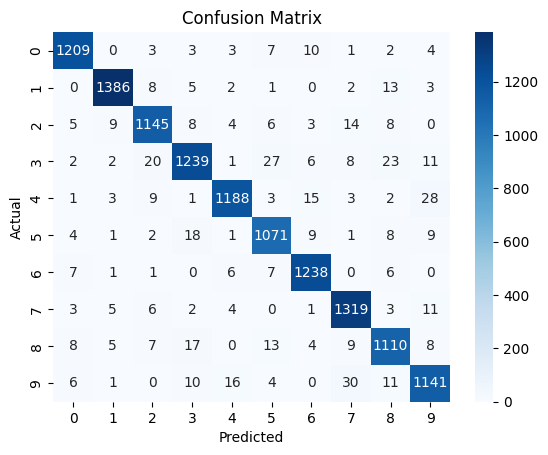

In [33]:
import seaborn as sns

# plt.figure(figsize=(3,3))
sns.heatmap(confusion_matrix(y_test, y_pred), fmt='d', cmap='Blues', annot=True)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

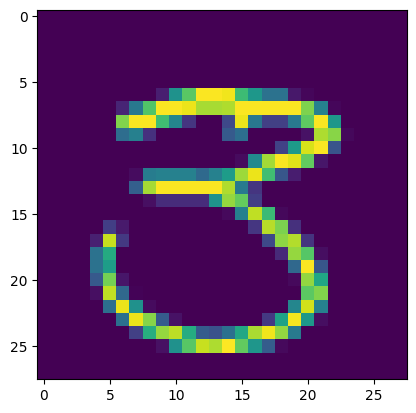

In [34]:
plt.imshow(x.iloc[7].values.reshape((28,28)))

In [61]:
import cv2
img_array=cv2.imread('predict3.png', 0) # 0 --> grayscale
img_array=cv2.resize(img_array, (28, 28)) # width, height


In [62]:
img_array=img_array.reshape((1,784))/255
img_array.shape

(1, 784)

In [63]:
res=model.predict(img_array)
res=np.argmax(res, axis=1)[0]
print(f"Your digit is {res}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Your digit is 6
